<a href="https://colab.research.google.com/github/Elvis-Kayonga/Data-Preprocessing-Formative2-ML-GROUP9/blob/model%2Fvoice_recignition/voice_recognition_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Audio Recognition System (Speaker Identification)

## Assignment: Audio Data Preprocessing

This notebook demonstrates:
- Audio data loading
- Feature extraction using MFCC
- Dataset creation
- Saving features to CSV
- Training a machine learning model for speaker recognition

The goal is to convert raw audio into numerical features that a machine learning model can understand.

In [16]:
#Install libraries
import librosa
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib
from sklearn.model_selection import cross_val_score

In [2]:
#mount drive that has the data folder and for storing model and features
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#access dataset
audio_folder = "/content/drive/MyDrive/voice_files"
files = os.listdir(audio_folder)
print(files)

['elvis_approve.wav', 'elvis_confirm.wav', 'paulette_approve.wav', 'paulette_confirm.wav', 'sharif_approve.wav', 'sharif_confirm.wav', 'samuel_approve.ogg', 'samuel_confirm.ogg']


## Dataset Preparation and cleaning pipeline

Each audio file is named using the format:

username_something.wav

1.we trim the audio files

2.we normalise them

3.we augment all every audio files

4.we plot the waveform and spectrogram for each file

5.we augment all every audio files

6.We extract:
- 13 MFCC features
- Spectral rolloff
- Energy

These features represent the voice characteristics of each speaker.

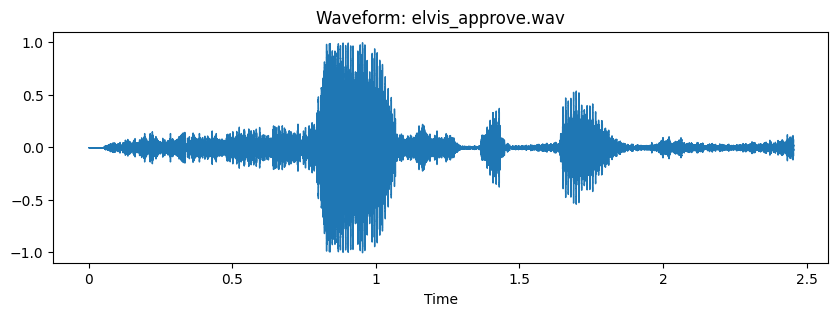

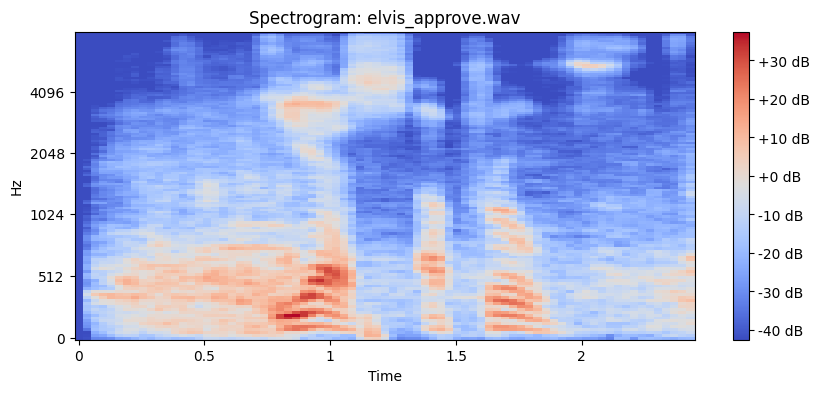

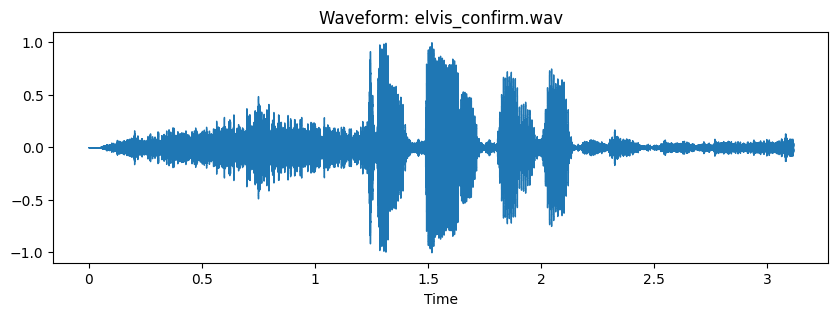

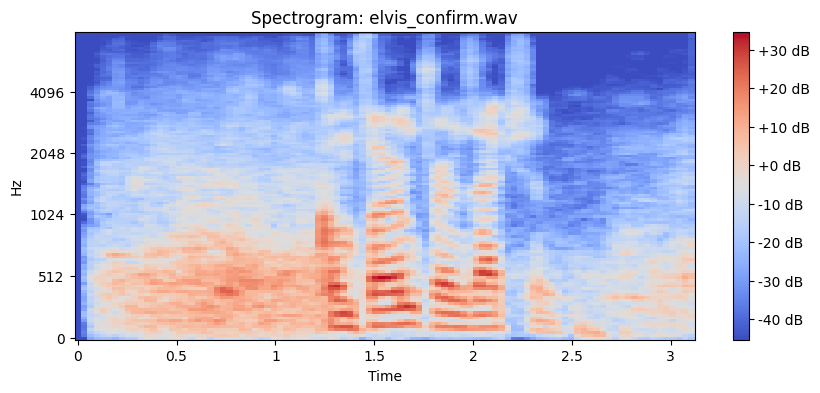

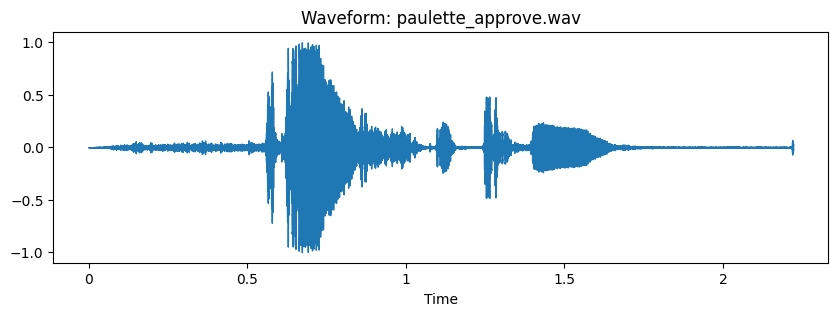

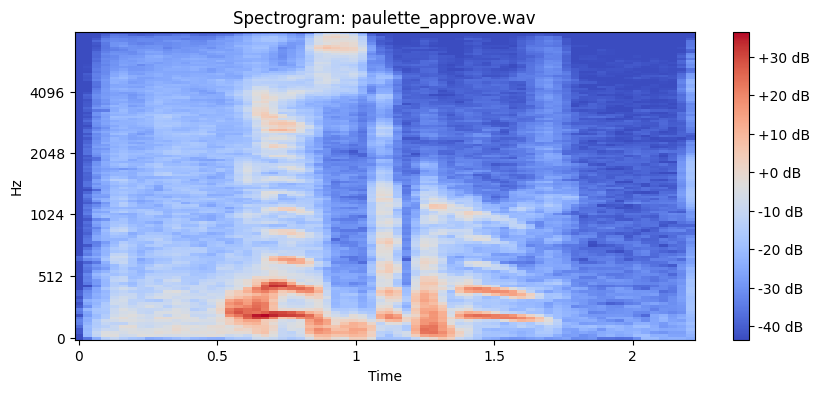

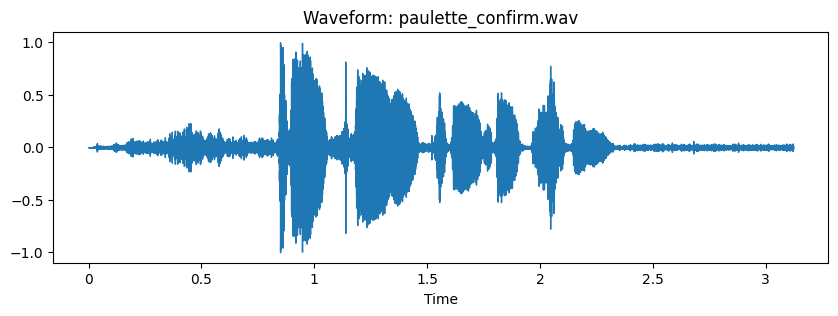

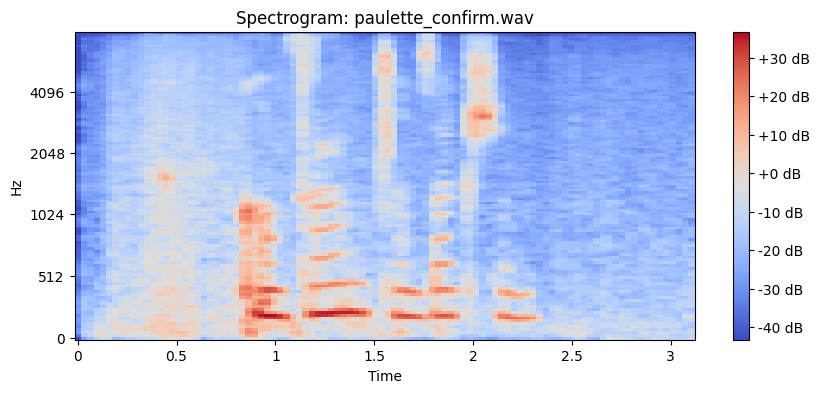

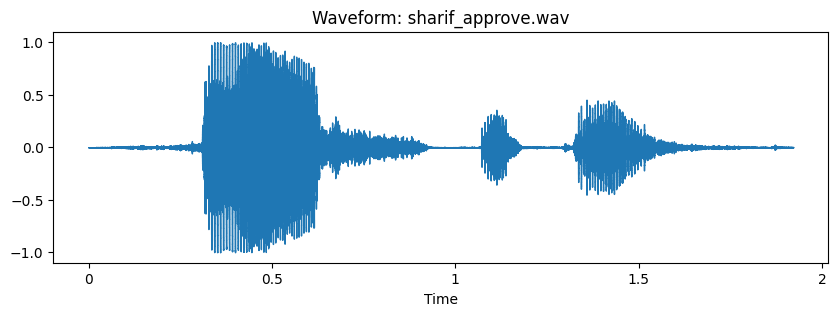

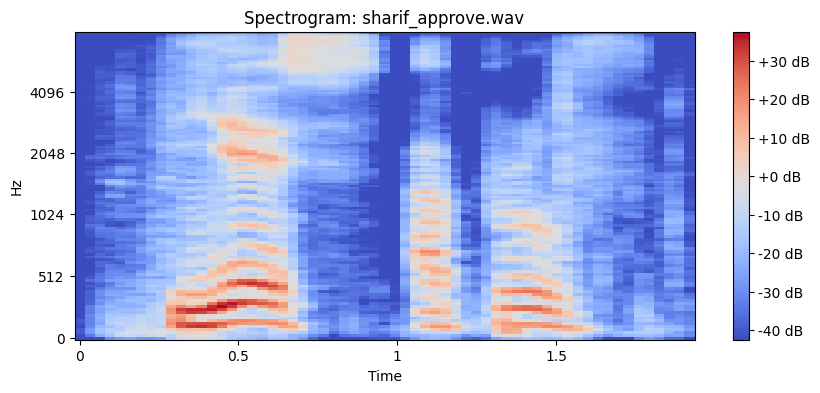

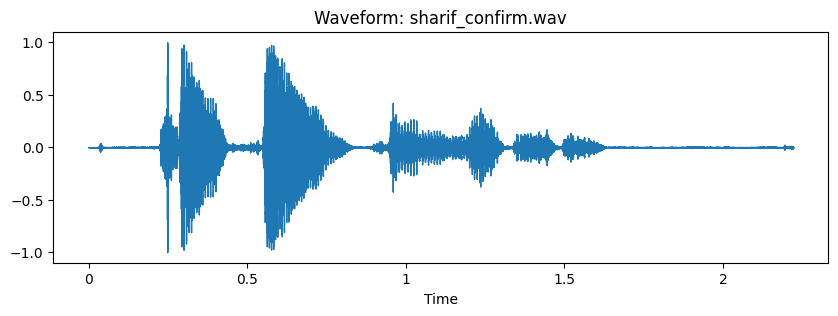

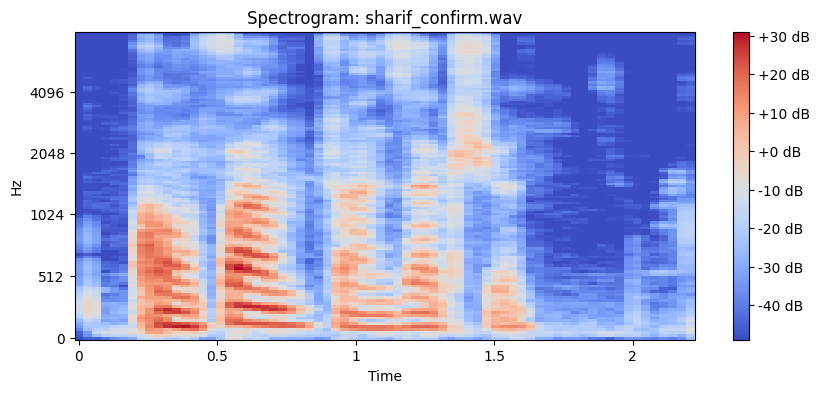

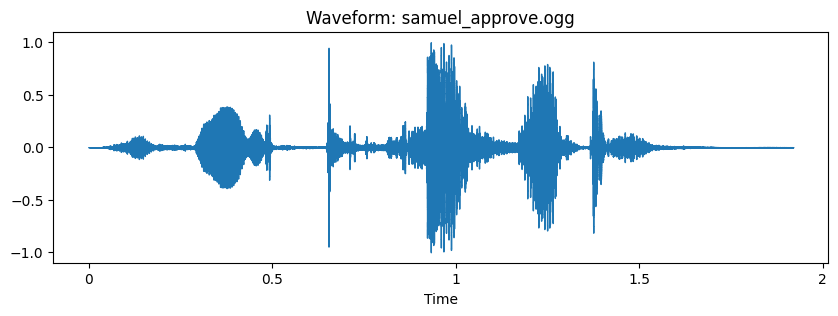

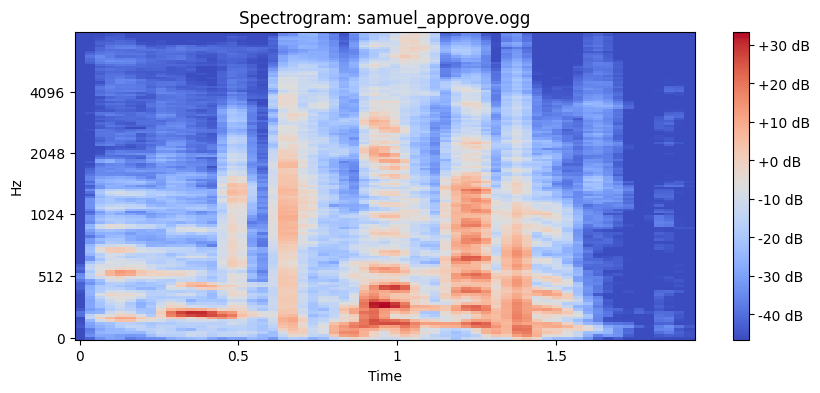

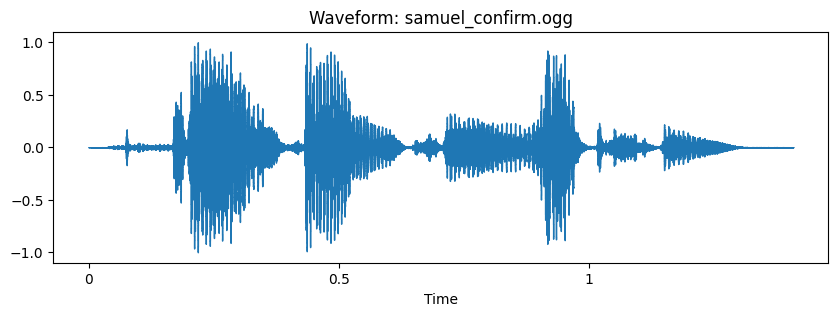

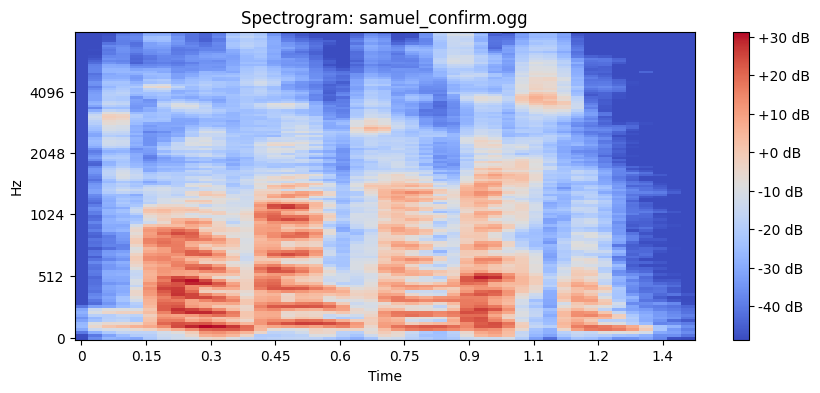

In [4]:
#Lists to store features and labels
features = []
labels = []

#loop through all audio files
for file in files:
  file_path = os.path.join(audio_folder, file)
  user = file.split('_')[0]
  y, sr = librosa.load(file_path, sr=16000)

  #audio cleaning
  y, _ = librosa.effects.trim(y)
  y = librosa.util.normalize(y)

  #visualisations
  plt.figure(figsize=(10,3))
  librosa.display.waveshow(y, sr=sr)
  plt.title(f"Waveform: {file}")
  plt.show()

  S = librosa.feature.melspectrogram(y=y, sr=sr)

  plt.figure(figsize=(10,4))
  librosa.display.specshow(librosa.power_to_db(S), sr=sr, x_axis='time', y_axis='mel')
  plt.title(f"Spectrogram: {file}")
  plt.colorbar(format='%+2.0f dB')
  plt.show()

    # Pitch shift
  y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=2)

    # Time stretch
  y_stretch = librosa.effects.time_stretch(y, rate=1.2)

    # Add noise
  noise = np.random.randn(len(y))
  y_noise = y + 0.005 * noise

  augmented_signals = [y, y_pitch, y_stretch, y_noise]


  for signal in augmented_signals:

      mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
      mfcc_mean = np.mean(mfcc.T, axis=0)

        # Additional required features
      rolloff = np.mean(librosa.feature.spectral_rolloff(y=signal, sr=sr))
      energy = np.mean(signal**2)

      feature_vector = np.append(mfcc_mean, [rolloff, energy])

      features.append(feature_vector)
      labels.append(user)

In [8]:
X = np.array(features)
y = np.array(labels)

df = pd.DataFrame(X)
df['user'] = y

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,user
0,-232.297943,118.182060,31.431736,15.253614,-19.873615,-5.467944,-13.181334,-15.564128,-4.116405,-0.405406,-8.431708,4.338981,-5.082498,2945.413961,0.023007,elvis
1,-253.496201,119.716103,30.399731,2.301518,-24.436180,-5.014936,-17.347176,-11.278334,-1.240483,-5.887691,-4.703166,1.434144,-11.254983,3055.803571,0.013247,elvis
2,-261.147614,120.215836,32.394081,14.735415,-21.777567,-4.094291,-13.483618,-14.910622,-5.657673,0.311545,-8.619177,5.711529,-4.896620,2913.940430,0.009194,elvis
3,-184.447920,80.305268,37.565104,12.153895,-14.512491,-6.434059,-13.707223,-12.961850,-4.962087,-2.792194,-3.513430,1.175741,-4.059584,4357.244318,0.023032,elvis
4,-203.462784,144.726089,-0.554127,28.893513,-13.392103,-13.847366,-10.420803,-13.329345,-8.025827,3.666438,-5.326194,-2.850114,-4.956906,1950.175383,0.020128,elvis


In [9]:
# Define the destination path directly in Google Drive
destination_path_drive = '/content/drive/MyDrive/voice_features/audio_features.csv'

# Create the destination folder if it doesn't exist
destination_folder = os.path.dirname(destination_path_drive)
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)

# Save the DataFrame directly to the specified Google Drive path
df.to_csv(destination_path_drive, index=False)
print(f"'audio_features.csv' saved directly to '{destination_path_drive}'")

'audio_features.csv' saved directly to '/content/drive/MyDrive/voice_features/audio_features.csv'


In [13]:
# Separate features and labels
X = df.drop("user", axis=1)
y = df["user"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, y_train.shape)
print("Data split completed.")

(25, 15) (25,)
Data split completed.


In [17]:
# Create model
model = RandomForestClassifier(n_estimators=100, random_state=42)

#cross validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print("CV Mean Accuracy:", cv_scores.mean())

# Train model
model.fit(X_train, y_train)

print("Model training completed.")

CV Mean Accuracy: 0.96
Model training completed.


In [19]:
# Make predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

       elvis       1.00      1.00      1.00         2
    paulette       1.00      1.00      1.00         1
      samuel       1.00      1.00      1.00         2
      sharif       1.00      1.00      1.00         2

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



In [20]:
# Save the trained model to Google Drive
model_path = "/content/drive/MyDrive/voice_features/speaker_model.pkl"

# Create folder if it doesn't exist
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save model
joblib.dump(model, model_path)

print("Model saved successfully!")

Model saved successfully!
